# 04 — Statistical Testing & Business Decision

## Context
This is the core of the analysis. We have an observed difference in completion rates between Test and Control. The question is: **is this difference statistically significant, and is it large enough to justify the cost of the UX change?**

### Two distinct questions
1. **Statistical significance** — Could the observed difference be due to random chance? We test this with a two-proportion z-test at α = 0.05.
2. **Business significance** — Even if statistically significant, is the lift large enough to matter? The business threshold is **5% relative lift** in completion rate.

These two questions are independent. A result can be statistically significant but too small to act on (large sample sizes make tiny effects detectable). Conversely, a meaningful lift in a small sample might not reach statistical significance.

### Why two-proportion z-test?
- Our outcome is binary: each client either completed or didn't
- Sample sizes are large enough for the normal approximation to hold
- We want to compare two independent proportions (Test vs Control)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
COLORS = {'Test': '#2563EB', 'Control': '#94A3B8'}
BUSINESS_THRESHOLD = 0.05  # 5% relative lift required
ALPHA = 0.05

df = pd.read_csv('../output/df_analysis_client_level.csv')
print(f'Loaded: {df.shape[0]:,} clients')

Loaded: 70,609 clients


## 1. Primary Metric Calculation

In [2]:
# Core numbers
test_df = df[df['Variation'] == 'Test']
ctrl_df = df[df['Variation'] == 'Control']

n_test = len(test_df)
n_ctrl = len(ctrl_df)
x_test = test_df['completed'].sum()   # completions in Test
x_ctrl = ctrl_df['completed'].sum()   # completions in Control

rate_test = x_test / n_test
rate_ctrl = x_ctrl / n_ctrl
abs_lift = rate_test - rate_ctrl
rel_lift = abs_lift / rate_ctrl

print(f'Test:    {x_test:,} / {n_test:,} = {rate_test:.4f} ({rate_test:.2%})')
print(f'Control: {x_ctrl:,} / {n_ctrl:,} = {rate_ctrl:.4f} ({rate_ctrl:.2%})')
print(f'\nAbsolute lift: {abs_lift:+.4f} ({abs_lift:+.2%})')
print(f'Relative lift: {rel_lift:+.4f} ({rel_lift:+.2%})')

Test:    18,518 / 26,968 = 0.6867 (68.67%)
Control: 15,262 / 23,532 = 0.6486 (64.86%)

Absolute lift: +0.0381 (+3.81%)
Relative lift: +0.0587 (+5.87%)


## 2. Two-Proportion Z-Test

In [3]:
# Two-sided z-test
count = np.array([x_test, x_ctrl])
nobs = np.array([n_test, n_ctrl])

z_stat, p_value = proportions_ztest(count, nobs, alternative='two-sided')

# 95% Confidence interval for each group
ci_test = proportion_confint(x_test, n_test, alpha=ALPHA, method='normal')
ci_ctrl = proportion_confint(x_ctrl, n_ctrl, alpha=ALPHA, method='normal')

# CI for the difference
se_diff = np.sqrt(rate_test*(1-rate_test)/n_test + rate_ctrl*(1-rate_ctrl)/n_ctrl)
z_crit = stats.norm.ppf(1 - ALPHA/2)
ci_diff_low = abs_lift - z_crit * se_diff
ci_diff_high = abs_lift + z_crit * se_diff

print('=== Statistical Test Results ===')
print(f'Z-statistic:         {z_stat:.4f}')
print(f'P-value:             {p_value:.6f}')
print(f'Significance level:  α = {ALPHA}')
print(f'\n95% CI (Test rate):    [{ci_test[0]:.4f}, {ci_test[1]:.4f}]')
print(f'95% CI (Control rate): [{ci_ctrl[0]:.4f}, {ci_ctrl[1]:.4f}]')
print(f'95% CI (Difference):   [{ci_diff_low:+.4f}, {ci_diff_high:+.4f}]')
print(f'\nStatistically significant: {"YES ✅" if p_value < ALPHA else "NO ❌"}')

=== Statistical Test Results ===
Z-statistic:         9.0761
P-value:             0.000000
Significance level:  α = 0.05

95% CI (Test rate):    [0.6811, 0.6922]
95% CI (Control rate): [0.6425, 0.6547]
95% CI (Difference):   [+0.0299, +0.0463]

Statistically significant: YES ✅


## 3. Effect Size (Cohen's h)

Cohen's h is the standard effect size measure for proportion differences. It accounts for the non-linearity of proportions (a 5pp lift from 10% to 15% is a bigger effect than from 50% to 55%).

In [4]:
# Cohen's h
phi_test = 2 * np.arcsin(np.sqrt(rate_test))
phi_ctrl = 2 * np.arcsin(np.sqrt(rate_ctrl))
cohens_h = abs(phi_test - phi_ctrl)

# Interpretation thresholds (Cohen 1988)
if cohens_h < 0.2:
    effect_label = 'Small'
elif cohens_h < 0.5:
    effect_label = 'Medium'
else:
    effect_label = 'Large'

print(f"Cohen's h: {cohens_h:.4f} → {effect_label} effect")

Cohen's h: 0.0809 → Small effect


## 5. Visualizations

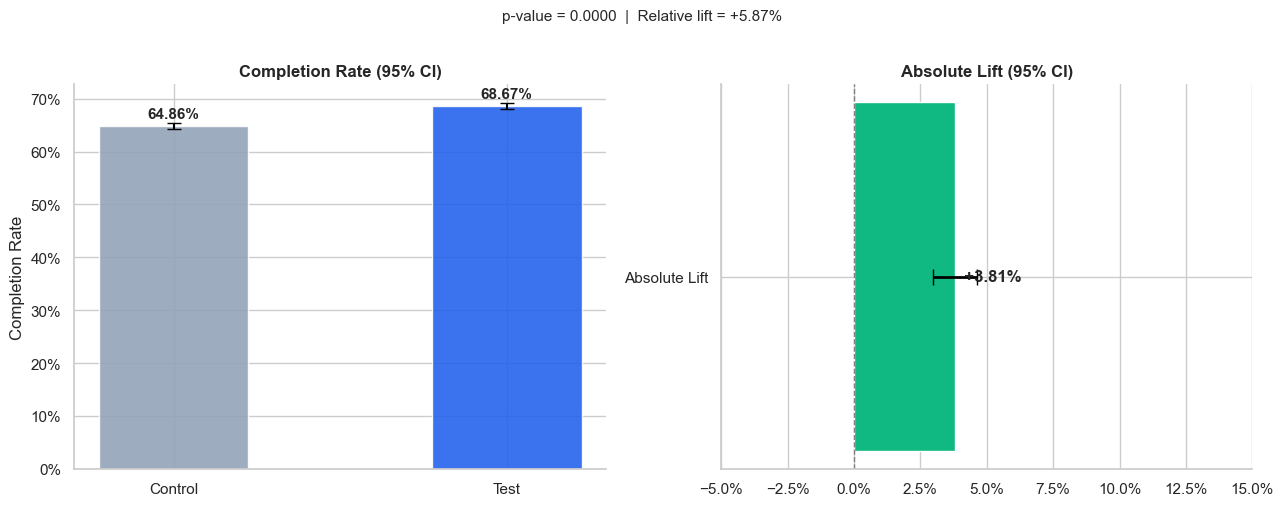

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: Completion rate comparison with CI ---
ax1 = axes[0]
groups = ['Control', 'Test']
rates = [rate_ctrl, rate_test]
ci_lows = [ci_ctrl[0], ci_test[0]]
ci_highs = [ci_ctrl[1], ci_test[1]]
colors = [COLORS['Control'], COLORS['Test']]

bars = ax1.bar(groups, rates, color=colors, width=0.45, edgecolor='white', alpha=0.9)
for bar, rate, lo, hi in zip(bars, rates, ci_lows, ci_highs):
    cx = bar.get_x() + bar.get_width() / 2
    ax1.errorbar(cx, rate, yerr=[[rate-lo], [hi-rate]], fmt='none', color='black', capsize=5, linewidth=1.5)
    ax1.text(cx, hi + 0.003, f'{rate:.2%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.set_title('Completion Rate (95% CI)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Completion Rate')
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
sns.despine(ax=ax1)

# --- Right: Lift with CI and threshold ---
ax2 = axes[1]
ax2.barh(['Absolute Lift'], [abs_lift], color='#10B981' if abs_lift > 0 else '#EF4444', height=0.3)
ax2.errorbar(abs_lift, 'Absolute Lift', xerr=[[abs_lift - ci_diff_low], [ci_diff_high - abs_lift]],
             fmt='none', color='black', capsize=6, linewidth=2)
ax2.axvline(0, color='gray', linewidth=1, linestyle='--')
ax2.text(abs_lift, 0, f'  {abs_lift:+.2%}', va='center', fontsize=12, fontweight='bold')
ax2.set_title('Absolute Lift (95% CI)', fontsize=12, fontweight='bold')
ax2.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax2.set_xlim(-0.05, 0.15)
sns.despine(ax=ax2)

plt.suptitle(f'p-value = {p_value:.4f}  |  Relative lift = {rel_lift:+.2%}', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('../output/statistical_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Save key results to a summary file for the Streamlit app
import json

results = {
    'rate_test': round(rate_test, 6),
    'rate_ctrl': round(rate_ctrl, 6),
    'abs_lift': round(abs_lift, 6),
    'rel_lift': round(rel_lift, 6),
    'z_stat': round(z_stat, 4),
    'p_value': round(p_value, 6),
    'ci_diff_low': round(ci_diff_low, 6),
    'ci_diff_high': round(ci_diff_high, 6),
    'cohens_h': round(cohens_h, 4),
    'effect_label': effect_label,
    'statistically_significant': bool(statistically_significant),
'exceeds_business_threshold': bool(exceeds_business_threshold),
    'n_test': n_test,
    'n_ctrl': n_ctrl,
    'x_test': int(x_test),
    'x_ctrl': int(x_ctrl)
}

with open('../output/results_summary.json', 'w') as f:
    json.dump(results, f, indent=2)

print('Results saved to output/results_summary.json')

Results saved to output/results_summary.json


## Summary

| Metric | Value |
|---|---|
| Test completion rate | 68.67% |
| Control completion rate | 64.86% |
| Absolute lift | +3.81 pp |
| Relative lift | +5.87% |
| Z-statistic | 9.08 |
| P-value | < 0.0001 |
| 95% Confidence interval | [+2.99 pp, +4.63 pp] |
| Cohen's h | 0.081 (Small) |
| Statistically significant (α = 0.05) | ✅ Yes |
| Exceeds 5% business threshold | ✅ Yes |

Both decision criteria are met. The result is highly unlikely to be due to chance, and the confidence interval confirms the true lift sits between +3.0 and +4.6 percentage points — entirely above zero. Effect size is small by Cohen's conventions, which is expected at this scale; what matters is that the lift is real, consistent, and crosses the business threshold.

**Business decision: Roll out — the new UX is effective.**